In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Initialize Spark session
spark = SparkSession.builder \
        .appName("testApp") \
        .master('local[5]') \
        .config("spark.driver.memory", "8g") \
        .config("spark.executor.memory", "10g") \
        .getOrCreate()

df2p = spark.read.parquet("file:///home/sh22/simulation/octupole/work/output/front50_2p/eDep")
df3n = spark.read.parquet("file:///home/sh22/simulation/octupole/work/output/front50_3n/eDep")
df2p.show(10)

24/12/11 20:15:42 WARN Utils: Your hostname, sha01 resolves to a loopback address: 127.0.1.1; using 10.32.2.20 instead (on interface enp94s0f1)
24/12/11 20:15:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/12/11 20:15:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+--------+-------+-------+------+------------------+
|workerId|eventId|detName|copyId|              eDep|
+--------+-------+-------+------+------------------+
|       7| 291663|     Si|   119| 0.742422431921607|
|       7| 291667|     Si|   121|1.0740763964758333|
|       7| 291669|     Si|   119| 2.083134662372769|
|       7| 291670|     Si|   114|5.0044740252593645|
|       7| 291676|     Si|   108|3.0341831318097703|
|       7| 291676|    CsI|     0| 7.467427617836463|
|       7| 291677|     Si|   118| 3.427100273083026|
|       7| 291680|     Si|   120|1.1491910062306625|
|       7| 291685|     Si|   115| 3.113037724322448|
|       7| 291687|     Si|   117| 3.888051159572208|
+--------+-------+-------+------+------------------+
only showing top 10 rows



Statistics:
[[0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 4.78134e+05 2.50000e+01]
 [0.00000e+00 4.01000e+02 0.00000e+00]]


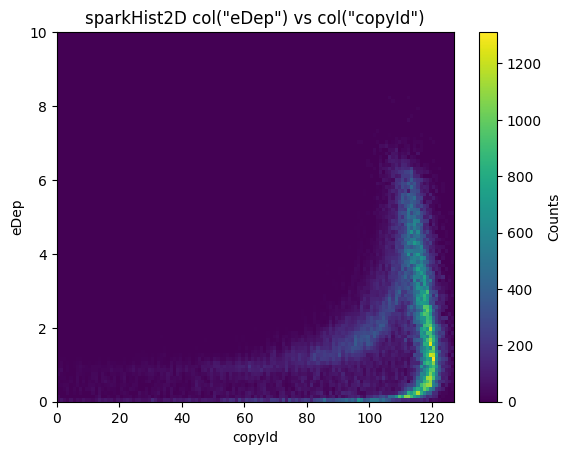

Statistics:
[[0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 5.21096e+05 7.10000e+01]
 [0.00000e+00 7.80000e+01 0.00000e+00]]


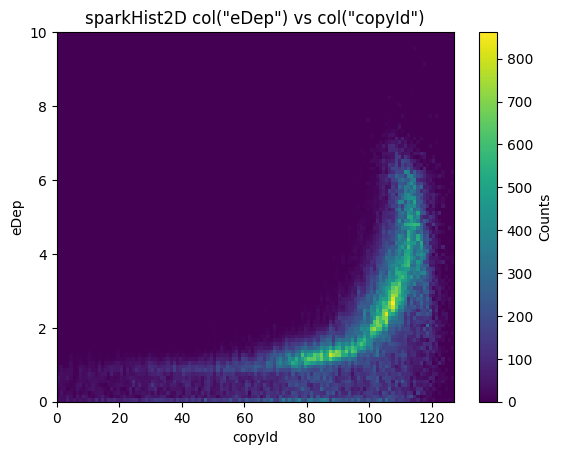

In [2]:
from matplotlib import pyplot
from hist.sparkHist2d import Hist2D
plt2 = Hist2D(df2p.filter(F.col("detName") == "Si"),["copyId","eDep"],[128,100],[[0,127],[0,10]])
plt2.show()
plt3 = Hist2D(df3n.filter(F.col("detName") == "Si"),["copyId","eDep"],[128,100],[[0,127],[0,10]])
plt3.show()

Statistics:
[[     0.      0.      0.]
 [     0. 156067.      0.]
 [     0.      0.      0.]]


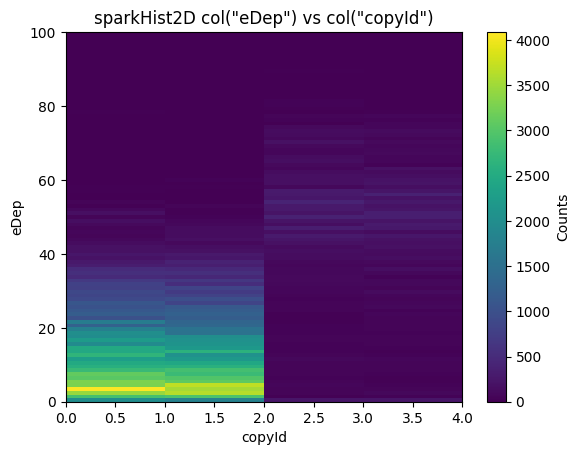

Statistics:
[[     0.      0.      0.]
 [     0. 345009.      0.]
 [     0.      0.      0.]]


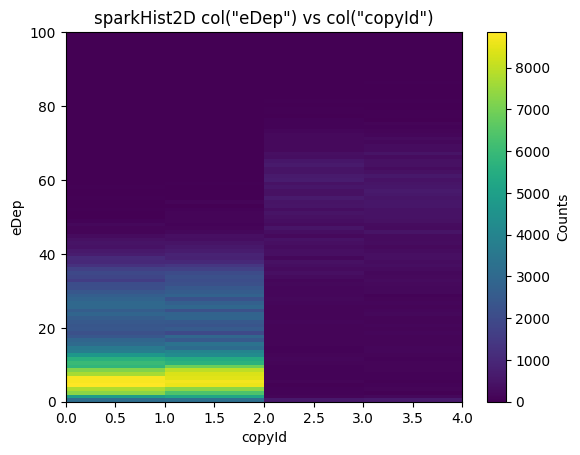

In [3]:
plt2 = Hist2D(df2p.filter(F.col("detName") == "CsI"),["copyId","eDep"],[5,100],[[0,4],[0,100]])
plt2.show()
plt3 = Hist2D(df3n.filter(F.col("detName") == "CsI"),["copyId","eDep"],[5,100],[[0,4],[0,100]])

In [4]:
df_evt2p= spark.read.parquet("file:///home/sh22/simulation/octupole/work/output/front50_2p/evtInfo")
df_evt3n= spark.read.parquet("file:///home/sh22/simulation/octupole/work/output/front50_3n/evtInfo")
df_join2p = df2p.join(df_evt2p,"eventId","left")
df_join3n = df3n.join(df_evt3n,"eventId","left")
df_join2p.show(10)

+-------+--------+-------+------+------------------+--------+------------------+------------------+------------------+
|eventId|workerId|detName|copyId|              eDep|workerId|           eProton|             theta|               phi|
+-------+--------+-------+------+------------------+--------+------------------+------------------+------------------+
| 208331|       5|     Si|   119| 0.742422431921607|       4| 9.770646970951876|1.2517941547401454|2.8748440289332433|
| 208331|       5|     Si|   119| 0.742422431921607|       5| 0.742422431921607|1.3841963375903994|1.7297505208595894|
| 208337|       5|     Si|   119| 2.083134662372769|       4|  20.6136376354627|1.1219299304304102|1.1536232311244232|
| 208337|       5|     Si|   119| 2.083134662372769|       5| 2.083134662372769|1.3745038253742712|1.4704999945743897|
| 208344|       5|     Si|   108|2.9757584553249647|       4|   62.968002169878|0.7353707673563856| 2.818479304372169|
| 208344|       5|     Si|   108|2.9757584553249

Statistics:
[[     0.      0.      0.]
 [     0. 628296.      0.]
 [     0.      0.      0.]]


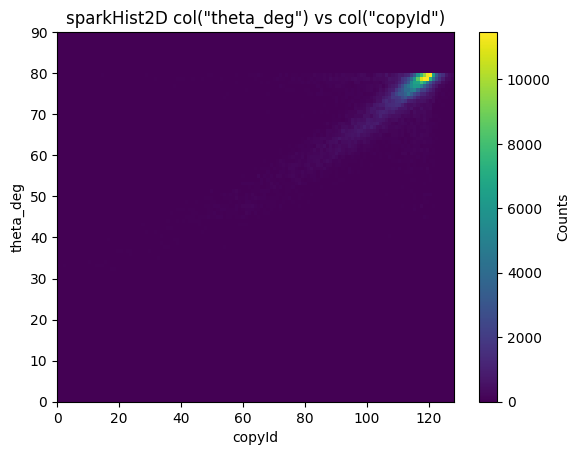

Statistics:
[[     0.      0.      0.]
 [     0. 687401.      0.]
 [     0.      0.      0.]]


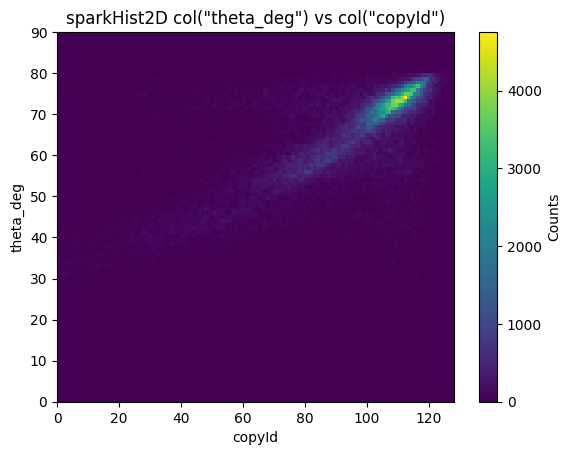

In [5]:
import numpy as np
df_si2p = df_join2p.filter(F.col("detName")=="Si")
df_si2p = df_si2p.select("eventId","copyId","eDep","eProton","theta","phi")
df_si2p = df_si2p.withColumn("theta_deg", F.col("theta")*F.lit(180./np.pi))
plt2p = Hist2D(df_si2p,["copyId","theta_deg"],[128,100],[[0,128],[0,90]])
plt2p.show()
df_si3n = df_join3n.filter(F.col("detName")=="Si")
df_si3n = df_si3n.select("eventId","copyId","eDep","eProton","theta","phi")
df_si3n = df_si3n.withColumn("theta_deg", F.col("theta")*F.lit(180./np.pi))
plt3n = Hist2D(df_si3n,["copyId","theta_deg"],[128,100],[[0,128],[0,90]])

Total entries: 466084, Underflow: 0, Inside: 466084, Overflow: 0
Total entries: 524505, Underflow: 0, Inside: 524505, Overflow: 0
[2.2000e+01 3.0000e+00 9.0000e+00 6.4000e+01 3.0000e+00 2.4000e+01
 5.1000e+01 1.7000e+01 1.6000e+01 7.9000e+01 3.7000e+01 9.0000e+00
 6.3000e+01 8.0000e+00 3.4000e+01 4.7000e+01 3.9000e+01 7.9000e+01
 1.3300e+02 6.0000e+01 6.8000e+01 1.1500e+02 7.8000e+01 9.8000e+01
 1.1700e+02 1.2200e+02 7.1000e+01 1.5900e+02 2.0500e+02 1.5200e+02
 1.5300e+02 9.9000e+01 1.1000e+02 1.5500e+02 2.4500e+02 1.1500e+02
 2.3600e+02 1.4100e+02 1.8700e+02 1.5600e+02 1.3200e+02 2.1100e+02
 1.4700e+02 1.4600e+02 2.3000e+02 2.2000e+02 2.3300e+02 3.0200e+02
 3.6500e+02 1.7400e+02 4.0200e+02 4.4400e+02 3.0400e+02 4.4800e+02
 2.9500e+02 6.1700e+02 7.1900e+02 3.9200e+02 5.9000e+02 6.3600e+02
 5.6500e+02 4.7700e+02 7.2100e+02 9.0500e+02 9.9100e+02 9.2100e+02
 1.2860e+03 1.2870e+03 1.6530e+03 1.7120e+03 1.8960e+03 1.7390e+03
 2.3020e+03 2.4640e+03 2.6330e+03 3.0810e+03 2.9350e+03 3.4350e+03

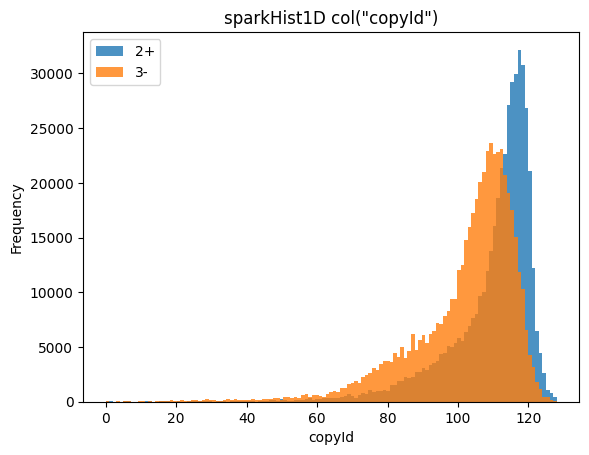

In [19]:
from hist.sparkHist1d import Hist1D
df_si2p_t = df_si2p.filter("eDep>1").withColumn("fcopy",F.col("copyId") + F.rand()).withColumn("theta_strip", F.expr("0.2667*(fcopy - 60) + 63"))
df_si3n_t = df_si3n.filter("eDep>1").withColumn("fcopy",F.col("copyId") + F.rand()).withColumn("theta_strip", F.expr("0.2667*(fcopy - 60) + 63"))
#bin_center2p, counts2p = Hist1D(df_si2p_t,"theta_strip",100,[45,90],alpha=0.8,label='2+')
#bin_center3n, counts3n = Hist1D(df_si3n_t,"theta_strip",100,[45,90],alpha=0.8,label='3-')
bin_center2p, counts2p = Hist1D(df_si2p_t,"copyId",128,[0,128],alpha=0.8,label='2+')
bin_center3n, counts3n = Hist1D(df_si3n_t,"copyId",128,[0,128],alpha=0.8,label='3-')
pyplot.legend()
pyplot.savefig('strip_dist.pdf')
print(counts3n)

1000000
1000000
Total entries: 221, Underflow: 0, Inside: 221, Overflow: 0
Total entries: 243, Underflow: 0, Inside: 243, Overflow: 0
[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.
  0.  0.  0.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  2.  0.  1.  1.  0.  1.  2.  0.
  3.  0.  1.  1.  3.  2.  0.  3.  2.  3.  4.  3.  0.  0.  5.  5.  3.  1.
  1.  2.  2.  3.  3.  6.  2.  3.  7.  2.  3.  8.  9. 13.  7. 11.  6. 14.
 11. 13.  9.  6.  6.  7.  9.  7.  5.  9.  2.  1.  3.  0.  1.  0.  1.  0.
  0.]


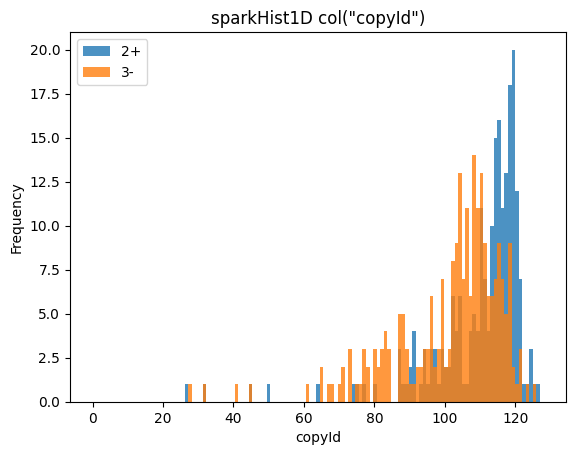

In [47]:
print(df_evt2p.count())
print(df_evt3n.count())
x2p, y2p = Hist1D(df_si2p_t.filter("eventId<600 AND eventId>0"),"copyId",128,[0,128],alpha=0.8,label='2+')
x3n, y3n = Hist1D(df_si3n_t.filter("eventId<600 AND eventId>0"),"copyId",128,[0,128],alpha=0.8,label='3-')
pyplot.legend()
print(y3n)

127
67
67


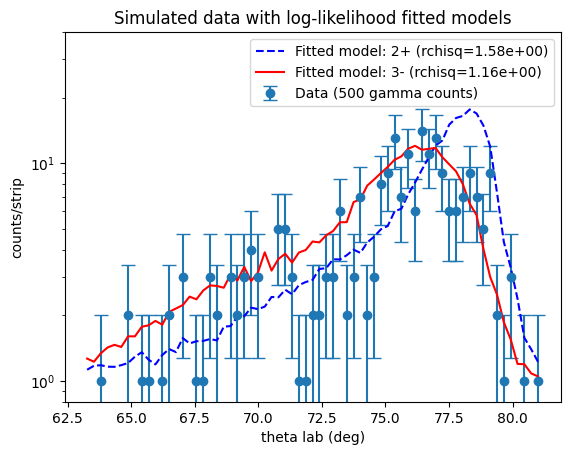

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln

# Example bin_centers, reference, and data arrays
bin_centers = 0.2667*(bin_center3n - 60) + 63
ref2p = counts2p
ref3n = counts3n
data = y3n  # Example with zeros in data

bin_centers = bin_centers[60:]
ref2p = ref2p[60:]
ref3n = ref3n[60:]
data = data[60:]
print(len(counts2p))
print(len(ref2p))
print(len(data))

# Create a new array with shifted entries
data_new = np.zeros_like(data)  # Initialize a new array with zeros
data_new[2:] = data[:-2]        # Shift entries by 3
data = data_new

# Length of the array
#length = len(data)
# Randomly select indices 'length' times (with replacement)
#random_indices = np.random.choice(length, size=length, replace=True)
# Add 1 to the selected indices
#np.add.at(data, random_indices, 1)

# Define the negative Poisson log-likelihood function
def negative_poisson_log_likelihood(c_init, ref, data):
    c, b = c_init
    #s = int(round(s))
    #model = c * np.roll(ref, s)
    model = c*ref 
    # Use data and model values in the Poisson log-likelihood
    # Avoid log(0) errors by adding a small epsilon to model
    epsilon = 1e-18
    model = np.clip(model, epsilon, None)  # Ensure model > 0
    nll = -np.sum(data * np.log(model) - model - gammaln(data + 1))
    return nll

# Initial guess for c
c_initial = [1.0e-3,1]

# Perform the optimization using Poisson log-likelihood
result2p = minimize(negative_poisson_log_likelihood, c_initial, args=(ref2p, data))
result3n = minimize(negative_poisson_log_likelihood, c_initial, args=(ref3n, data))

# Get the best-fit parameter c
c_opt2p = result2p.x[0]
c_opt3n = result3n.x[0]

# Calculate the fitted data
fitted_data2p = c_opt2p * ref2p + result2p.x[1]
fitted_data3n = c_opt3n * ref3n + result3n.x[1]

# Calculate Poisson deviance
def poisson_deviance(data, model):
    epsilon = 1e-18
    model = np.clip(model, epsilon, None)  # Ensure model > 0
    dev = 2 * np.sum(data * np.log(np.clip(data / model, epsilon, None)) - (data - model))
    return dev
    
# Calculate chi-square statistic
def chi_square(data, model):
    epsilon = 1e-18  # To avoid division by zero
    return np.sum((data - model)**2 / np.clip(model, epsilon, None))

# Compute chi-square value
chi_square_value2p = chi_square(data, fitted_data2p)
chi_square_value3n = chi_square(data, fitted_data3n)
# Calculate degrees of freedom
dof = len(data) - 1  # One parameter (c) is fitted
# Compute reduced chi-square
reduced_chi_square2p = chi_square_value2p / dof
reduced_chi_square3n = chi_square_value3n / dof

# Compute deviance
#deviance_value = poisson_deviance(data, fitted_data)

# Plot data with error bars and the fitted model as a line using bin_centers
plt.errorbar(bin_centers, data, yerr=np.sqrt(data + 1e-18), fmt='o', label='Data (500 gamma counts)', capsize=5)
plt.plot(bin_centers, fitted_data2p, 'b--', label=f'Fitted model: 2+ (rchisq={reduced_chi_square2p:.2e})')
plt.plot(bin_centers, fitted_data3n, 'r-', label=f'Fitted model: 3- (rchisq={reduced_chi_square3n:.2e})')

# Add labels and a legend
plt.xlabel('theta lab (deg)')
plt.ylabel('counts/strip')
plt.title('Simulated data with log-likelihood fitted models')
plt.yscale('log')
plt.ylim(8e-1,40)
plt.legend()

# Show the plot
plt.show()

#print(f"Optimized constant c (Poisson MLE): {c_opt}")
#print(f"Reduced chi-square: {reduced_chi_square2p}")
#print(f"Poisson deviance: {deviance_value}")

In [74]:
import numpy as np
from scipy.stats import chi2

# Chi-square values and degrees of freedom
chi_square_ref1 = 1.02
chi_square_ref2 = 4.17
#chi_square_ref1 = 1.35
#chi_square_ref2 = 2.8

dof = len(data) - 1  # Assuming one fitted parameter
chi_square_ref1 = chi_square_ref1 * dof
chi_square_ref2 = chi_square_ref2 * dof
# CDF of the chi-square distribution for ref1 and ref2
p_value_ref1 = chi2.cdf(chi_square_ref1, dof)
p_value_ref2 = chi2.cdf(chi_square_ref2, dof)

# Probability of getting chi_square_ref1 or less under the ref2 model
prob_ref1_given_ref2 = p_value_ref1

# Print the p-values
print(f"dof: {dof}")
print(f"P(chi^2 <= {chi_square_ref1}) under ref2's chi-square distribution: {prob_ref1_given_ref2:.20f}")
print(f"P(chi^2 <= {chi_square_ref2}) under ref2's chi-square distribution: {p_value_ref2:.20f}")

dof: 126
P(chi^2 <= 117.18) under ref2's chi-square distribution: 0.29914313823724320018
P(chi^2 <= 575.82) under ref2's chi-square distribution: 1.00000000000000000000
